###### DSM500 - MSc Thesis: Investigating the Performance and Reliability of Deep-Learning Flood Segmentation Under Varying Flood Extent Using Sentinel-1 SAR Imagery
###### 5 August 2026
###### Archie Hulse
###### Student Number: 250410903
##### Notebook 3: 
#                                               03 - <u>Experimental Design<u/>
--------------------------------

#### <u>Contents:</u>
###### *(Hyperlinks to sections of this report)*

[1.1](#1.1) Import Libraries, Define Paths & Load Data

[2.1](#2.1) Research Question Definition

[3.1](#3.1) Hypotheses Definition

[4.1](#4.1) Models Definition

[5.1](#5.1) Experimental Variable Definition

[6.1](#6.1) Flood-extent Distribution & Grouping

[7.1](#7.1) Evaluation Metrics Definition

[8.1](#8.1) Experimental Controls Definition

[9.1](#9.1) Experiment Structure Definition

[10.1](#10.1) Experimental Table

------------------------------

###### 1.1
### Section 1.1 — Import Libraries, Define Paths & Load Data:

In [36]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
# Project root directory:
# The project root is identified as the first parent directory containing both the Data and Results folders.

def find_project_root():
    current = Path.cwd().resolve()

    for directory in [current] + list(current.parents):
        if (directory / "Data").exists() and (directory / "Results").exists():
            return directory

    raise FileNotFoundError("Could not locate the project root. ""Make sure the repository contains Data/ and Results/ folders.")


PROJECT_DIR = find_project_root()

DATA_DIR = PROJECT_DIR / "Data"
RESULTS_DIR = PROJECT_DIR / "Results"
TABLE_DIR = RESULTS_DIR / "tables"

METADATA_FILE = TABLE_DIR / "chip_dataTable.csv"
BOLIVIA_METADATA_FILE = TABLE_DIR / "bolivia_holdout_dataTable.csv"

print("Project directory :", PROJECT_DIR)
print("Metadata file     :", METADATA_FILE)
print("Bolivia metadata  :", BOLIVIA_METADATA_FILE)

Project directory : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project
Metadata file     : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Results/tables/chip_dataTable.csv
Bolivia metadata  : /Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Results/tables/bolivia_holdout_dataTable.csv


In [38]:
# Load prepared overview metadata generated in Notebook 02:

metadata = pd.read_csv(METADATA_FILE)

# Load unseen Bolivia holdout separately:
bolivia_metadata = pd.read_csv(BOLIVIA_METADATA_FILE)

print("Main experimental dataset:", metadata.shape)
print("Bolivia holdout dataset  :", bolivia_metadata.shape)

Main experimental dataset: (426, 12)
Bolivia holdout dataset  : (15, 12)


In [39]:
# Checks to verify use of correct data:

print("Dataset summary")
print("-" * 40)

print("Total chips:", len(metadata))
print("Unique chip IDs:", metadata["s1_id"].nunique())
print("Flood events:", metadata["flood_event"].nunique())

print("\nSplit counts:")
print(metadata["split"].value_counts())

print("\nFlood events:")
print(metadata["flood_event"].value_counts())

print("\nFlood extent statistics:")
print(metadata["flood_extent_percent"].describe())

Dataset summary
----------------------------------------
Total chips: 426
Unique chip IDs: 426
Flood events: 10

Split counts:
split
train         251
test           89
validation     86
Name: count, dtype: int64

Flood events:
flood_event
USA          69
India        68
Paraguay     67
Ghana        48
Sri-Lanka    42
Mekong       30
Spain        30
Pakistan     28
Somalia      26
Nigeria      18
Name: count, dtype: int64

Flood extent statistics:
count    426.000000
mean      10.655133
std       19.062733
min        0.000000
25%        0.532184
50%        2.491298
75%       11.190923
max      100.000000
Name: flood_extent_percent, dtype: float64


In [40]:
# Check for Data Leakage:
# Verify that Bolivia is not present in the main experimental dataset.

main_events = set(metadata["flood_event"].unique())
holdout_events = set(bolivia_metadata["flood_event"].unique())

print("Main dataset flood events:")
print(sorted(main_events))

print("\nHoldout flood events:")
print(sorted(holdout_events))

assert "Bolivia" not in main_events, ("Bolivia has leaked into the main experimental dataset.")
assert holdout_events == {"Bolivia"}, ("The holdout metadata contains an unexpected flood event.")

print("\n✓ Bolivia is completely separated from the main experiment.")

Main dataset flood events:
['Ghana', 'India', 'Mekong', 'Nigeria', 'Pakistan', 'Paraguay', 'Somalia', 'Spain', 'Sri-Lanka', 'USA']

Holdout flood events:
['Bolivia']

✓ Bolivia is completely separated from the main experiment.


-----------------------
###### 2.1
### Section 2.1 — Define Research Question:

In [41]:
RESEARCH_QUESTION = (
    "How does variation in flood extent affect the performance and "
    "reliability of deep-learning flood segmentation models using "
    "Sentinel-1 SAR imagery?")

print("Research question:")
print(RESEARCH_QUESTION)

Research question:
How does variation in flood extent affect the performance and reliability of deep-learning flood segmentation models using Sentinel-1 SAR imagery?


--------------------
###### 3.1
### Section 3.1 — Define Hypotheses:

In [42]:
HYPOTHESES = {
    "H1": ("Segmentation performance decreases as flood extent becomes smaller."),
    
    "H2": ("The reduction in segmentation performance is disproportionately "
        "greater at very small flood extents than at moderate or large flood extents."),
    
    "H3": ("The effect of decreasing flood extent differs between CNN-based "
        "and transformer-based segmentation architectures.")}

for hypothesis, statement in HYPOTHESES.items():
    print(f"{hypothesis}: {statement}\n")

H1: Segmentation performance decreases as flood extent becomes smaller.

H2: The reduction in segmentation performance is disproportionately greater at very small flood extents than at moderate or large flood extents.

H3: The effect of decreasing flood extent differs between CNN-based and transformer-based segmentation architectures.



-----------------------
###### 4.1
### Section 4.1 — Define Models:

In [43]:
# Models selected for the controlled experiment.

MODELS = {
    "U-Net": {"architecture_type": "CNN", "role": "Baseline"},
    
    "SegFormer": {"architecture_type": "Transformer", "role": "Modern comparison"}
}

models_df = pd.DataFrame(MODELS).T
display(models_df)

,architecture_type,role
U-Net,CNN,Baseline
SegFormer,Transformer,Modern comparison


------------------------------
###### 5.1
### Section 5.1 — Define Experimental Variable:

In [44]:
# Primary explanatory variable:

EXPERIMENTAL_VARIABLE = "flood_extent_percent"

print("Primary explanatory variable:")
print(EXPERIMENTAL_VARIABLE)

Primary explanatory variable:
flood_extent_percent


In [45]:
VARIABLE_DEFINITION = (
    "Flood extent is the percentage of valid pixels within an image chip "
    "operationally treated as event-associated flood water, calculated from "
    "LabelHand water pixels after accounting for permanent water using the "
    "corresponding JRCWaterHand mask."
)

print(VARIABLE_DEFINITION)

Flood extent is the percentage of valid pixels within an image chip operationally treated as event-associated flood water, calculated from LabelHand water pixels after accounting for permanent water using the corresponding JRCWaterHand mask.


-------------------------------
###### 6.1
### Section 6.1 - Flood-extent Distribution & Grouping:

In [46]:
# Flood extent distribution shown here is based on the preliminary
# metadata variable generated during data exploration.
#
# The final experimental flood-extent measure is recalculated from the
# LabelHand and JRCWaterHand masks in Notebook 04 using the JRC-adjusted
# definition established in the dissertation methodology.

extent = metadata["flood_extent_percent"]

print("Flood extent distribution")
print("-" * 40)

print(f"Minimum : {extent.min():.3f}%")
print(f"Maximum : {extent.max():.3f}%")
print(f"Mean    : {extent.mean():.3f}%")
print(f"Median  : {extent.median():.3f}%")
print(f"Std     : {extent.std():.3f}%")

Flood extent distribution
----------------------------------------
Minimum : 0.000%
Maximum : 100.000%
Mean    : 10.655%
Median  : 2.491%
Std     : 19.063%


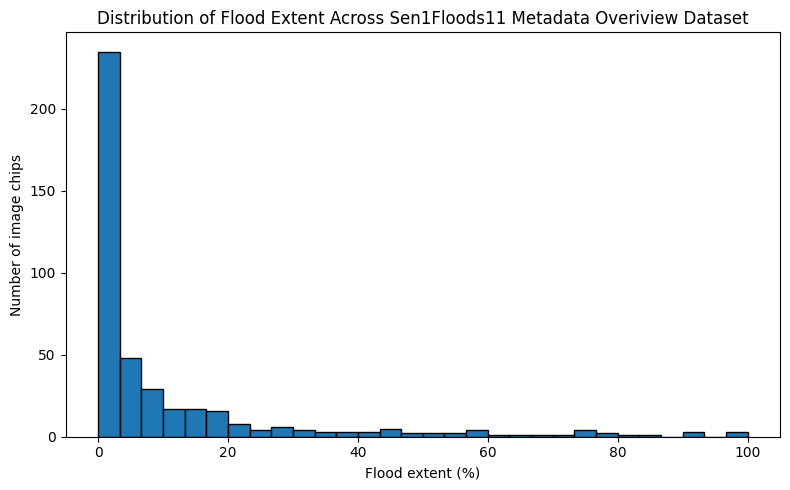

In [47]:
# Plot to visualise the Distribution of Flood Extent Across the data:

plt.figure(figsize=(8, 5))
plt.hist(extent, bins=30, edgecolor="black")
plt.xlabel("Flood extent (%)")
plt.ylabel("Number of image chips")
plt.title("Distribution of Flood Extent Across Sen1Floods11 Metadata Overiview Dataset")
plt.tight_layout()
plt.show()

In [48]:
# Initial flood-extent categories for exploratory analysis:

# These categories are intended to describe the distribution of the data.
# The final analysis will also retain flood extent as a continuous variable.

extent_bins = [-0.001, 1, 5, 10, 25, 50, 100.001]
extent_labels = ["0–1%", "1–5%", "5–10%", "10–25%", "25–50%", ">50%"]

metadata["flood_extent_group"] = pd.cut(metadata["flood_extent_percent"], bins=extent_bins,
    labels=extent_labels, include_lowest=True, right=True)

print(metadata["flood_extent_group"].value_counts().sort_index())

flood_extent_group
0–1%      145
1–5%      121
5–10%      46
10–25%     60
25–50%     28
>50%       26
Name: count, dtype: int64


------------------------------
###### 7.1
### Section 7.1 — Defined Evaluation Metrics:

In [49]:
EVALUATION_METRICS = {
    "IoU": {"role": "Primary segmentation metric"},
    "F1": {"role": "Secondary segmentation metric"},
    "Precision": {"role": "False-positive behaviour"},
    "Recall": {"role": "Flood detection completeness"}
}

metrics_df = pd.DataFrame(EVALUATION_METRICS).T
display(metrics_df)

,role
IoU,Primary segmentation metric
F1,Secondary segmentation metric
Precision,False-positive behaviour
Recall,Flood detection completeness


---------------------------
###### 8.1
### Section 8.1 — Defined Experimental Controls:

In [50]:
EXPERIMENTAL_CONTROLS = {
    "Dataset": "Both models use identical image chips.",
    
    "Ground truth": "Both models use identical hand-labelled masks.",
    
    "Preprocessing": "Identical Sentinel-1 preprocessing and normalisation.",
    
    "Augmentation": "Identical augmentation strategy for both models.",
    
    "Data split": "Official train/validation/test split is fixed.",
    
    "Evaluation": "Both models are evaluated on the same test chips.",
    
    "Metrics": "Both models are evaluated using identical metrics.",
    
    "Loss function": "The same primary loss function is used initially.",
    
    "Training budget": "Comparable training and optimisation budgets.",
    
    "Random seeds": "Random seeds are controlled for reproducibility.",
    
    "Holdout": "The Bolivia flood event remains completely unseen."
}

for control, description in EXPERIMENTAL_CONTROLS.items():
    print(f"{control}:")
    print(f"  {description}\n")

Dataset:
  Both models use identical image chips.

Ground truth:
  Both models use identical hand-labelled masks.

Preprocessing:
  Identical Sentinel-1 preprocessing and normalisation.

Augmentation:
  Identical augmentation strategy for both models.

Data split:
  Official train/validation/test split is fixed.

Evaluation:
  Both models are evaluated on the same test chips.

Metrics:
  Both models are evaluated using identical metrics.

Loss function:
  The same primary loss function is used initially.

Training budget:
  Comparable training and optimisation budgets.

Random seeds:
  Random seeds are controlled for reproducibility.

Holdout:
  The Bolivia flood event remains completely unseen.



---------------------
###### 9.1
### Section 9 — Defined Experiment Structure:

In [51]:
EXPERIMENTAL_STRUCTURE = {
    "Independent variable": "Flood extent (%)",
    
    "Dependent variables": [
        "IoU",
        "F1",
        "Precision",
        "Recall"
    ],
    
    "Model factor": [
        "U-Net",
        "SegFormer"
    ],
    
    "Primary relationship":
        "Flood extent → segmentation performance",
    
    "Architecture interaction":
        "Flood extent × architecture → segmentation performance"
}

for key, value in EXPERIMENTAL_STRUCTURE.items():
    print(f"{key}: {value}")

Independent variable: Flood extent (%)
Dependent variables: ['IoU', 'F1', 'Precision', 'Recall']
Model factor: ['U-Net', 'SegFormer']
Primary relationship: Flood extent → segmentation performance
Architecture interaction: Flood extent × architecture → segmentation performance


----------------------
###### 10.1
### Section 10.1 - Experimental Table:

In [52]:
experiment_metadata = metadata[
    ["s1_id", "split", "flood_event", "width",
        "height", "flood_extent_percent", "flood_extent_group"]].copy()

print("Experimental metadata shape:", experiment_metadata.shape)
display(experiment_metadata.head())

Experimental metadata shape: (426, 7)


,s1_id,split,flood_event,width,height,flood_extent_percent,flood_extent_group
0,Ghana_103272,train,Ghana,512,512,0.600920,0–1%
1,Ghana_24858,train,Ghana,512,512,0.184631,0–1%
2,Ghana_147015,train,Ghana,512,512,1.346588,1–5%
3,Ghana_953791,train,Ghana,512,512,1.057434,1–5%
4,Ghana_154838,train,Ghana,512,512,0.000000,0–1%


In [53]:
experimental_metadata_file = (TABLE_DIR / "experiment_design_dataTable.csv")

experiment_metadata.to_csv(experimental_metadata_file, index=False)

print(f"✓ Experimental metadata saved to:")
print(experimental_metadata_file)

✓ Experimental metadata saved to:
/Users/archiewilliamhulse/Desktop/Msc Data Science/Final Project/DSM500 Final Project/Results/tables/experiment_design_dataTable.csv


In [54]:
# Final experimental design checks:

assert experiment_metadata["s1_id"].is_unique
assert experiment_metadata["flood_extent_percent"].notna().all()
assert set(experiment_metadata["split"].unique()) == {"train", "validation", "test"}
assert "Bolivia" not in set(experiment_metadata["flood_event"])
assert set(MODELS.keys()) == {"U-Net", "SegFormer"}
assert "IoU" in EVALUATION_METRICS
assert "F1" in EVALUATION_METRICS

print("✓ Experimental design passed all checks.")

✓ Experimental design passed all checks.
